# Fair Bandwidth Allocation via Power Cones

**Alpha-fairness optimization with Moreau** — the first power cone example in the gallery.

This notebook demonstrates:
- **Power cone constraints** — `cp.power(x, p, approx=False)` maps to Moreau's `Cones(power_alphas=[...])`
- **Alpha-fairness** — the `sum(x_i^p / p)` objective trades off throughput and equality
- **Fairness-throughput tradeoff** — sweep the fairness parameter and visualize the Pareto frontier
- **Bilevel capacity planning** — learn optimal link capacities by differentiating through the fair allocation solver via cvxpylayers

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import cvxpy as cp
import moreau
from cvxpylayers.torch import CvxpyLayer

from utils.style import set_moreau_style, set_moreau_dark_style, MOREAU_COLORS, moreau_gradient
from utils.animation import fig_to_pil, save_gif, display_gif

set_moreau_style()
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## The Alpha-Fairness Problem

A network operator allocates bandwidth $x_i$ to $n$ users sharing $m$ links.
Each user's traffic traverses a subset of links described by a routing matrix $R$,
so the capacity constraint is $Rx \le c$.

The **alpha-fairness** objective generalizes several classical notions:

$$\max_x \; \sum_{i=1}^n \frac{x_i^{\,p}}{p} \quad \text{s.t.} \quad Rx \le c, \; x \ge \varepsilon$$

| $p$ | Name | Behavior |
|-----|------|----------|
| $1$ | Throughput-maximizing | All bandwidth to highest-capacity users |
| $0.5$ | Square-root fairness | Moderate sharing |
| $p \to 0$ | Proportional fairness | Maximizes $\sum \log x_i$ |

For $0 < p < 1$, each term $x_i^p$ is a **power function** that CVXPY models with
`cp.power(x, p, approx=False)`. This introduces a 3-dimensional power cone constraint per user:

$$t_i \le x_i^p \cdot 1^{1-p} \;\Longleftrightarrow\; (x_i,\; 1,\; t_i) \in \mathcal{K}_{\text{pow}}^{\,p}$$

where $\mathcal{K}_{\text{pow}}^{\alpha} = \{(u,v,w) : u^\alpha v^{1-\alpha} \ge |w|,\; u,v \ge 0\}$.

In [2]:
# --- Network setup ---
n_users = 20
n_links = 12
epsilon = 0.01

# Random routing matrix: each user traverses 2-4 links
R = np.zeros((n_links, n_users))
for j in range(n_users):
    n_hops = np.random.randint(2, 5)  # 2-4 links
    links = np.random.choice(n_links, size=n_hops, replace=False)
    R[links, j] = 1.0

# Heterogeneous link capacities
c_base = np.random.uniform(1.5, 4.0, size=n_links)

# Summary stats
density = R.sum() / R.size
links_per_user = R.sum(axis=0)
users_per_link = R.sum(axis=1)
print(f"Network: {n_users} users, {n_links} links")
print(f"Routing matrix density: {density:.1%}")
print(f"Links per user: {links_per_user.mean():.1f} avg ({links_per_user.min():.0f}-{links_per_user.max():.0f})")
print(f"Users per link: {users_per_link.mean():.1f} avg ({users_per_link.min():.0f}-{users_per_link.max():.0f})")
print(f"Link capacities: {c_base.min():.2f} to {c_base.max():.2f} (total: {c_base.sum():.1f})")

Network: 20 users, 12 links
Routing matrix density: 27.5%
Links per user: 3.3 avg (2-4)
Users per link: 5.5 avg (3-7)
Link capacities: 1.54 to 3.84 (total: 30.8)


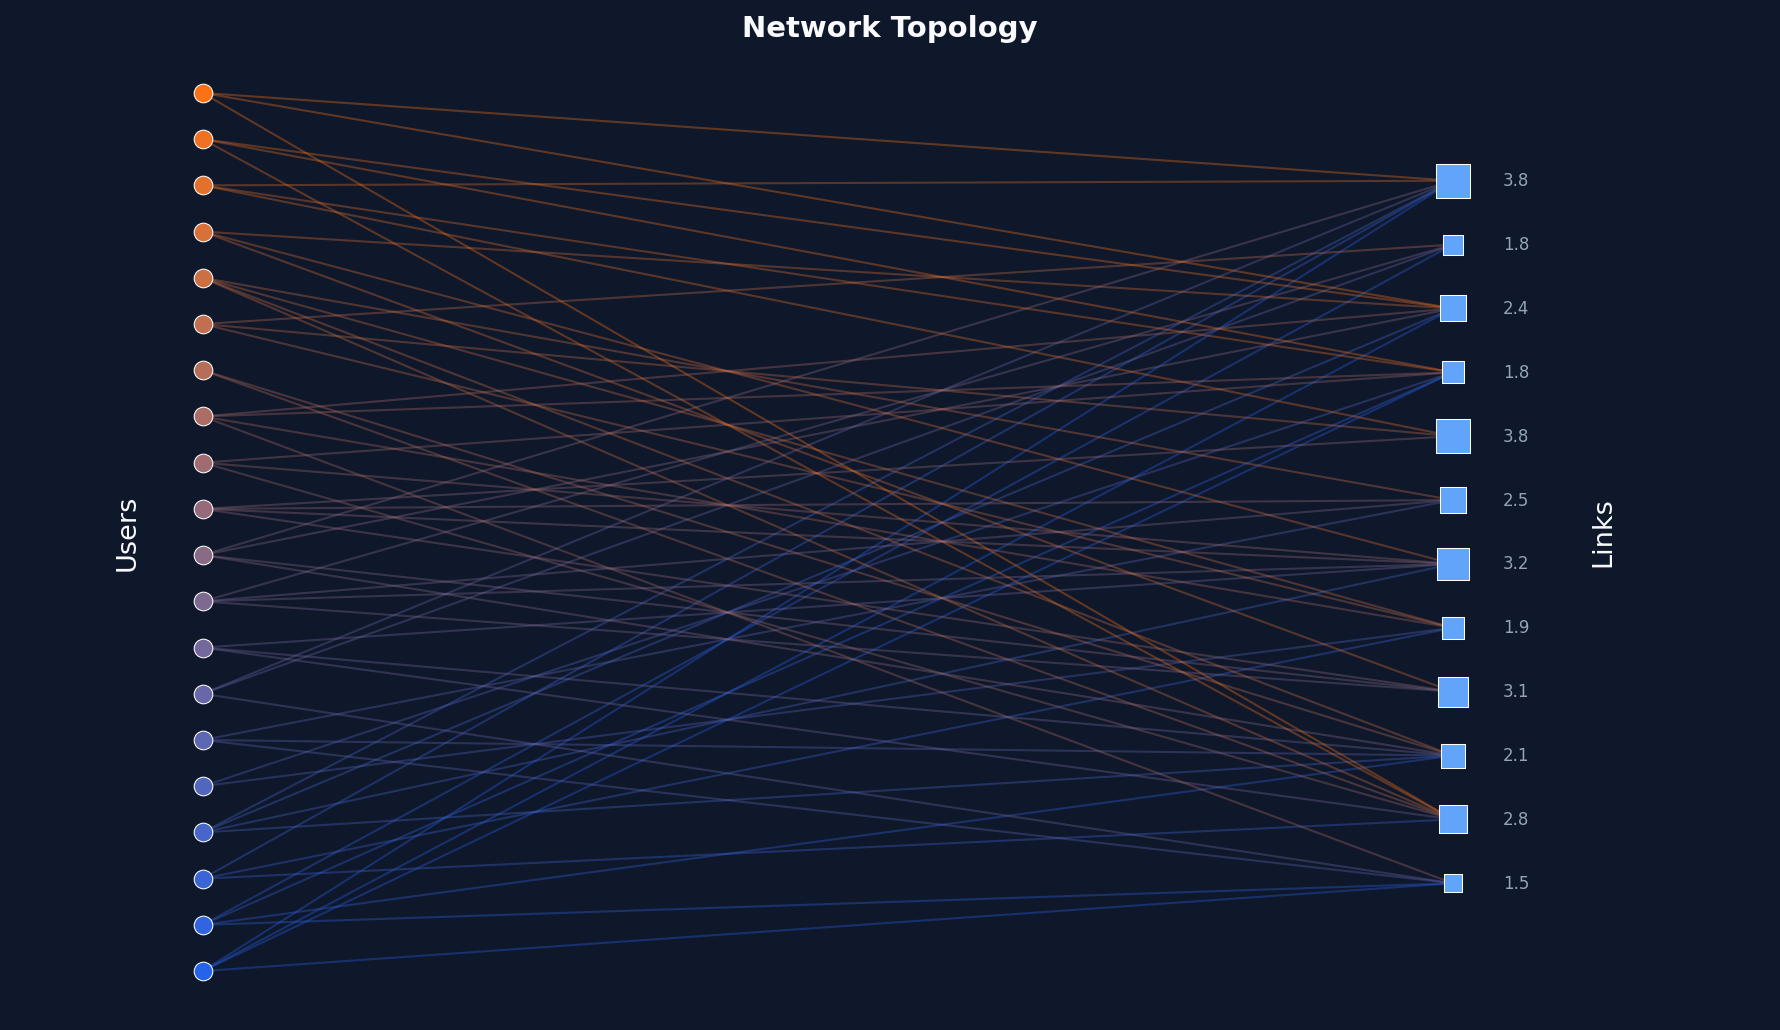

In [3]:
# --- Bipartite network visualization ---
set_moreau_dark_style()
fig, ax = plt.subplots(figsize=(12, 7))

# Layout: users on the left, links on the right
user_x = np.zeros(n_users)
user_y = np.linspace(0, 1, n_users)
link_x = np.ones(n_links)
link_y = np.linspace(0.1, 0.9, n_links)

# Draw connections
user_colors = moreau_gradient(n_users)
for j in range(n_users):
    for i in range(n_links):
        if R[i, j] > 0:
            ax.plot([user_x[j], link_x[i]], [user_y[j], link_y[i]],
                    color=user_colors[j], alpha=0.35, linewidth=1.0)

# Users (circles)
for j in range(n_users):
    ax.scatter(user_x[j], user_y[j], s=80, color=user_colors[j],
               edgecolors='white', linewidth=0.5, zorder=5)

# Links (squares, sized by capacity)
cap_norm = (c_base - c_base.min()) / (c_base.max() - c_base.min())
for i in range(n_links):
    size = 80 + 200 * cap_norm[i]
    ax.scatter(link_x[i], link_y[i], s=size, marker='s',
               color=MOREAU_COLORS['primary_light'], edgecolors='white',
               linewidth=0.5, zorder=5)
    ax.annotate(f'{c_base[i]:.1f}', (link_x[i] + 0.04, link_y[i]),
                fontsize=8, color=MOREAU_COLORS['text_secondary'], va='center')

ax.text(-0.06, 0.5, 'Users', ha='center', va='center', fontsize=13,
        color=MOREAU_COLORS['text'], rotation=90)
ax.text(1.12, 0.5, 'Links', ha='center', va='center', fontsize=13,
        color=MOREAU_COLORS['text'], rotation=90)
ax.set_xlim(-0.15, 1.25)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('auto')
ax.axis('off')
ax.set_title('Network Topology', fontsize=14)
plt.tight_layout()
plt.show()
set_moreau_style()

## Single Allocation (p = 0.5)

Fix $p = 0.5$ (square-root fairness). Each user contributes a power cone:

$$(x_i,\; 1,\; t_i) \in \mathcal{K}_{\text{pow}}^{0.5} \;\Longleftrightarrow\; t_i \le x_i^{0.5}$$

Moreau represents these as `Cones(power_alphas=[0.5, ...])` — 20 power cones of dimension 3.

In [4]:
# --- Solve single allocation with p = 0.5 ---
x_var = cp.Variable(n_users, nonneg=True)
p_val = 0.5
objective = cp.Maximize(cp.sum(cp.power(x_var, p_val, approx=False)) / p_val)
constraints = [R @ x_var <= c_base, x_var >= epsilon]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.MOREAU)

rates = x_var.value
throughput = rates.sum()
jain = rates.sum()**2 / (n_users * (rates**2).sum())  # Jain's fairness index

print(f"Status: {prob.status}")
print(f"Objective: {prob.value:.4f}")
print(f"Total throughput: {throughput:.2f}")
print(f"Jain's fairness index: {jain:.4f} (1.0 = perfect equality)")
print(f"Rate range: [{rates.min():.4f}, {rates.max():.4f}]")
print(f"Mean rate: {rates.mean():.4f}")

Status: optimal
Objective: 25.4028
Total throughput: 9.04
Jain's fairness index: 0.6655 (1.0 = perfect equality)
Rate range: [0.0977, 1.4828]
Mean rate: 0.4520


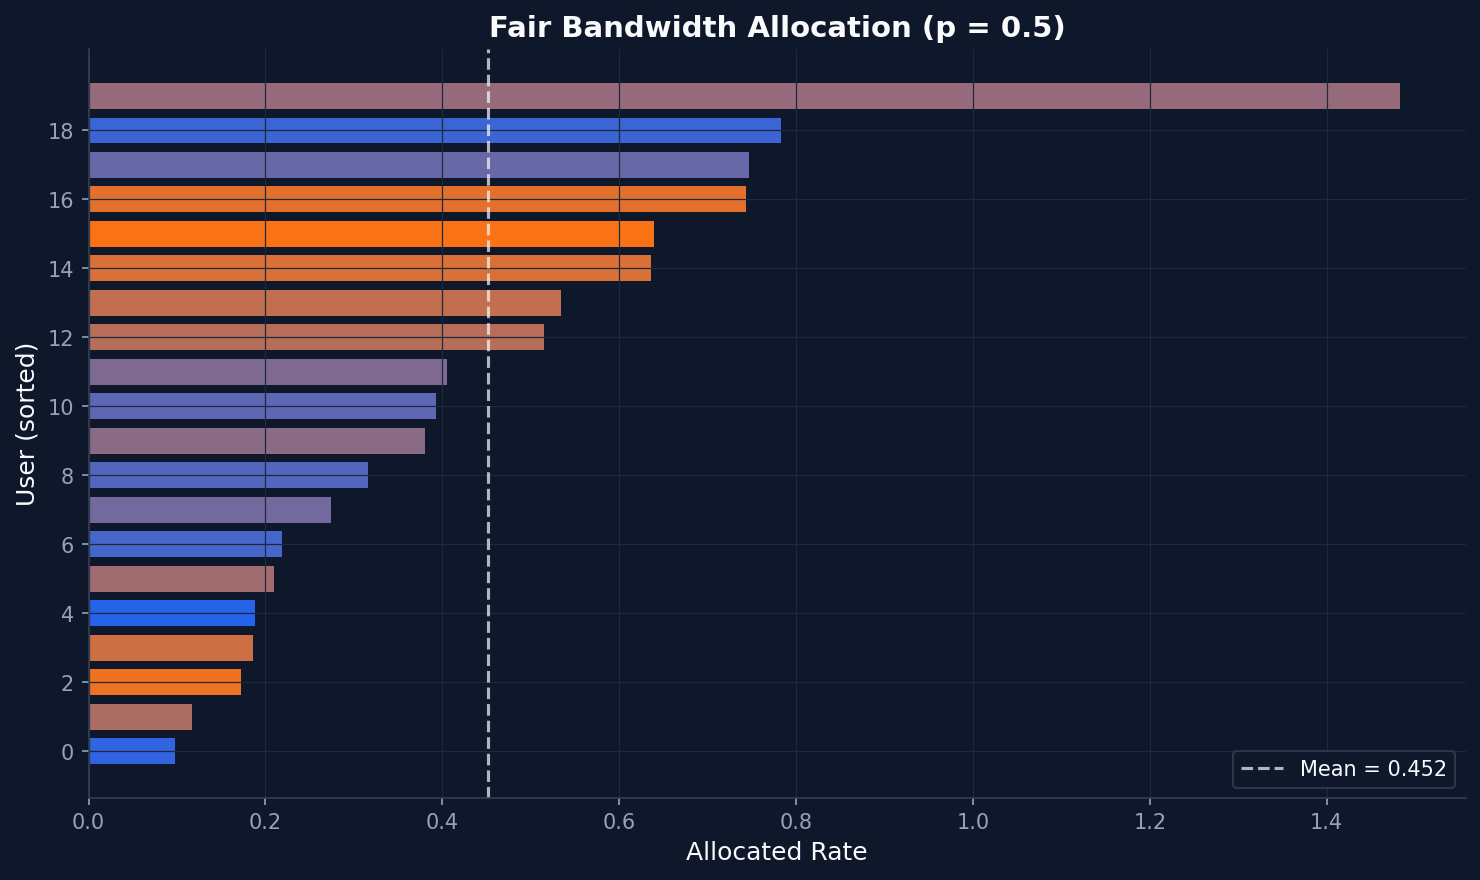

In [5]:
# --- Per-user rate bar chart ---
set_moreau_dark_style()
fig, ax = plt.subplots(figsize=(10, 6))

order = np.argsort(rates)
colors = moreau_gradient(n_users)

ax.barh(range(n_users), rates[order], color=[colors[i] for i in order],
        edgecolor='none', height=0.75)
ax.axvline(rates.mean(), color=MOREAU_COLORS['text'], linestyle='--',
           linewidth=1.5, alpha=0.7, label=f'Mean = {rates.mean():.3f}')
ax.set_xlabel('Allocated Rate')
ax.set_ylabel('User (sorted)')
ax.set_title(f'Fair Bandwidth Allocation (p = {p_val})', fontsize=14)
ax.legend(loc='lower right', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155')
ax.set_yticks(range(0, n_users, 2))
plt.tight_layout()
plt.show()
set_moreau_style()

## Fairness Parameter Sweep

Sweep $p$ from 0.1 to 0.95. Each value of $p$ creates a different power cone $\mathcal{K}_{\text{pow}}^p$,
so the cone structure changes with each solve — no batching possible here.

Lower $p$ &#x2192; more equal rates (higher fairness, lower throughput).
Higher $p$ &#x2192; throughput-maximizing (lower fairness, higher throughput).

In [6]:
# --- Fairness parameter sweep ---
p_values = np.linspace(0.1, 0.95, 15)

sweep_rates = []      # per-user rates for each p
sweep_throughput = []  # total throughput
sweep_jain = []        # Jain's fairness index
sweep_min = []         # min rate
sweep_max = []         # max rate
sweep_mean = []        # mean rate

for p in p_values:
    x_v = cp.Variable(n_users, nonneg=True)
    obj = cp.Maximize(cp.sum(cp.power(x_v, p, approx=False)) / p)
    cons = [R @ x_v <= c_base, x_v >= epsilon]
    prob_sweep = cp.Problem(obj, cons)
    prob_sweep.solve(solver=cp.MOREAU)

    r = x_v.value
    sweep_rates.append(r.copy())
    sweep_throughput.append(r.sum())
    sweep_jain.append(r.sum()**2 / (n_users * (r**2).sum()))
    sweep_min.append(r.min())
    sweep_max.append(r.max())
    sweep_mean.append(r.mean())

sweep_throughput = np.array(sweep_throughput)
sweep_jain = np.array(sweep_jain)
sweep_min = np.array(sweep_min)
sweep_max = np.array(sweep_max)
sweep_mean = np.array(sweep_mean)

print(f"Solved {len(p_values)} problems")
print(f"Throughput range: {sweep_throughput.min():.2f} to {sweep_throughput.max():.2f}")
print(f"Jain's index range: {sweep_jain.min():.4f} to {sweep_jain.max():.4f}")

Solved 15 problems
Throughput range: 8.52 to 10.17
Jain's index range: 0.4653 to 0.7406


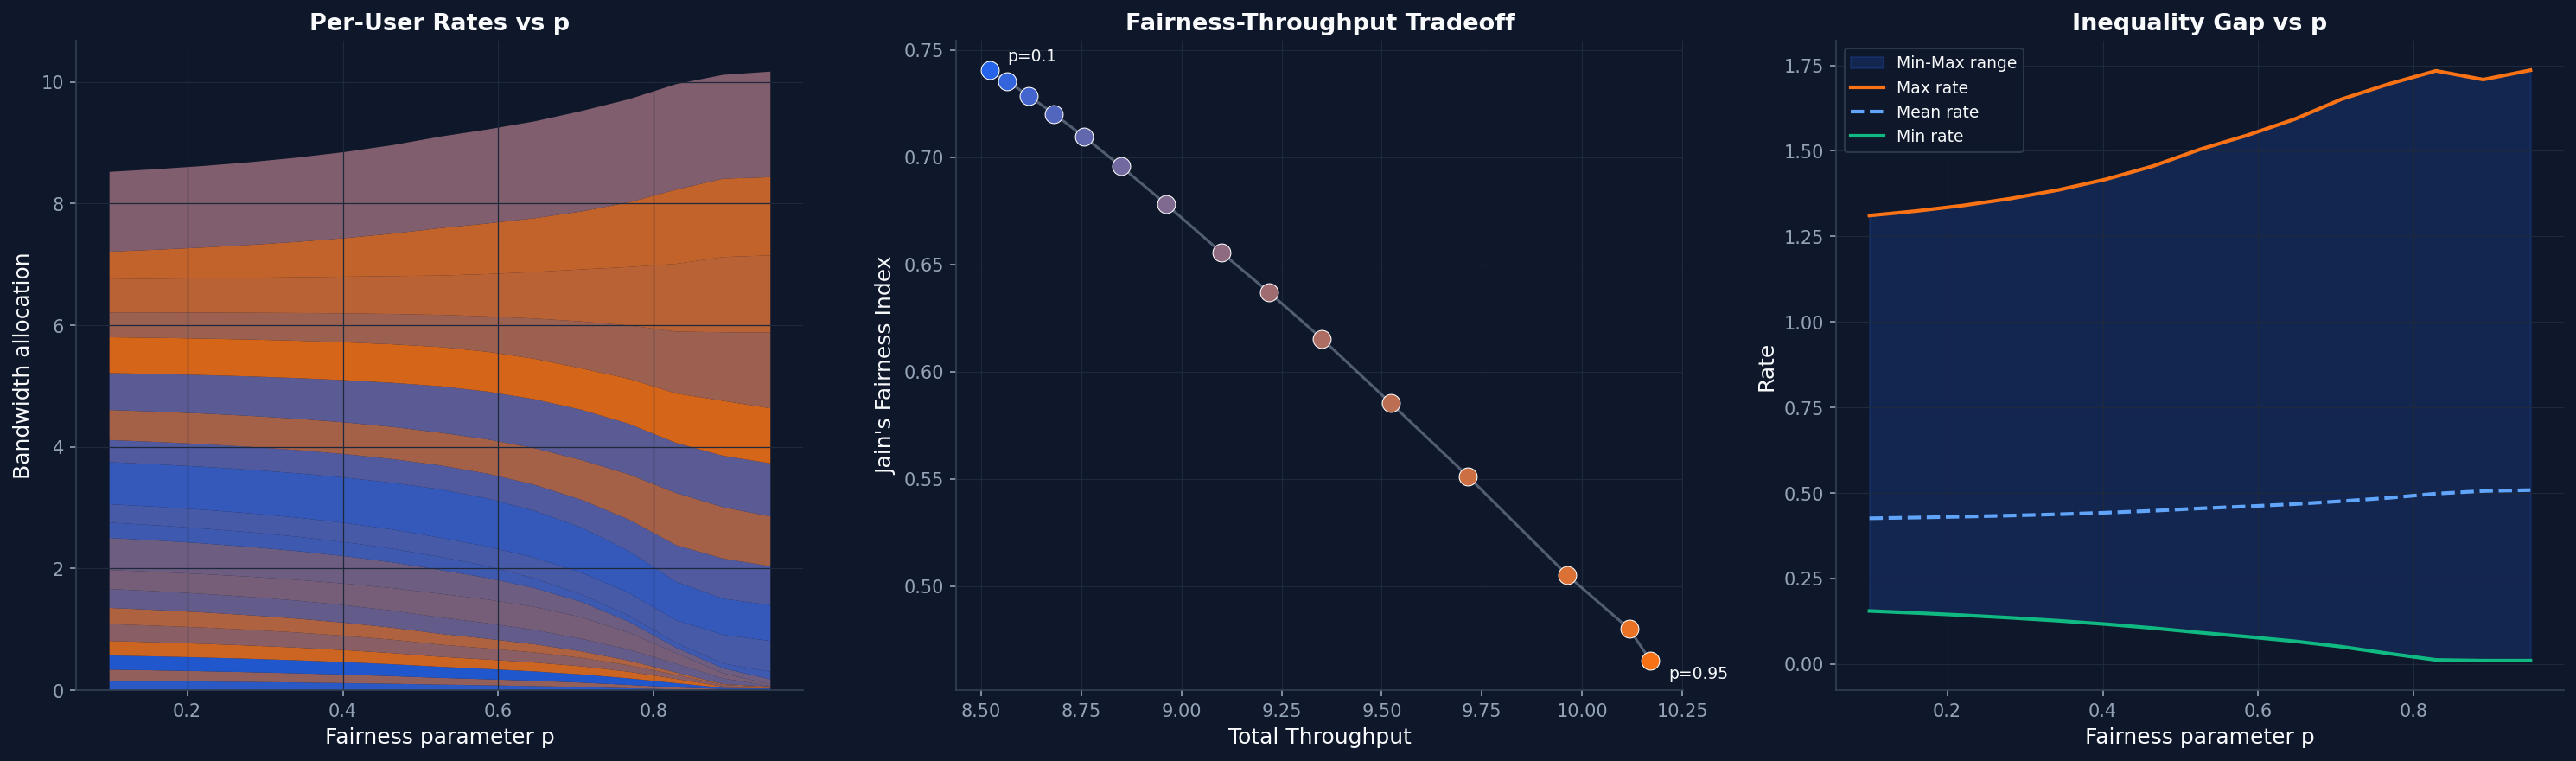

In [7]:
# --- 3-panel sweep visualization ---
set_moreau_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Stacked area — per-user rates vs p
ax = axes[0]
rates_matrix = np.array(sweep_rates)  # (n_p, n_users)
sorted_idx = np.argsort(rates_matrix[-1])  # sort by final (high-p) rates
rates_sorted = rates_matrix[:, sorted_idx]
user_colors = moreau_gradient(n_users)
ax.stackplot(p_values, rates_sorted.T,
             colors=[user_colors[i] for i in sorted_idx], alpha=0.85)
ax.set_xlabel('Fairness parameter p')
ax.set_ylabel('Bandwidth allocation')
ax.set_title('Per-User Rates vs p', fontsize=13)

# Panel 2: Pareto frontier — Jain's fairness vs throughput
ax = axes[1]
p_colors = moreau_gradient(len(p_values))
for k in range(len(p_values)):
    ax.scatter(sweep_throughput[k], sweep_jain[k], color=p_colors[k],
               s=100, zorder=5, edgecolors='white', linewidth=0.5)
ax.plot(sweep_throughput, sweep_jain, color=MOREAU_COLORS['text_secondary'],
        linewidth=1.5, alpha=0.5, zorder=3)
# Label endpoints
ax.annotate(f'p={p_values[0]:.1f}', (sweep_throughput[0], sweep_jain[0]),
            fontsize=9, color=MOREAU_COLORS['text'],
            xytext=(10, 5), textcoords='offset points')
ax.annotate(f'p={p_values[-1]:.2f}', (sweep_throughput[-1], sweep_jain[-1]),
            fontsize=9, color=MOREAU_COLORS['text'],
            xytext=(10, -10), textcoords='offset points')
ax.set_xlabel('Total Throughput')
ax.set_ylabel("Jain's Fairness Index")
ax.set_title('Fairness-Throughput Tradeoff', fontsize=13)

# Panel 3: Min/max/mean rate vs p
ax = axes[2]
ax.fill_between(p_values, sweep_min, sweep_max,
                color=MOREAU_COLORS['primary'], alpha=0.2, label='Min-Max range')
ax.plot(p_values, sweep_max, color=MOREAU_COLORS['accent'], linewidth=2, label='Max rate')
ax.plot(p_values, sweep_mean, color=MOREAU_COLORS['primary_light'],
        linewidth=2, linestyle='--', label='Mean rate')
ax.plot(p_values, sweep_min, color=MOREAU_COLORS['success'], linewidth=2, label='Min rate')
ax.set_xlabel('Fairness parameter p')
ax.set_ylabel('Rate')
ax.set_title('Inequality Gap vs p', fontsize=13)
ax.legend(loc='upper left', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155', fontsize=9)

plt.tight_layout()
plt.show()
set_moreau_style()

## Power Cones Under the Hood

The 3-dimensional **power cone** is defined as:

$$\mathcal{K}_{\text{pow}}^{\alpha} = \{(u, v, w) \in \mathbb{R}^3 : u^\alpha \, v^{1-\alpha} \ge |w|, \; u,v \ge 0\}$$

Moreau represents these via `Cones(power_alphas=[α₁, α₂, ...])`. Each alpha defines one
3-dimensional power cone, consuming 3 rows of the constraint matrix.

For our allocation problem with 20 users and $p = 0.5$: **20 power cones = 60 constraint rows**
dedicated to the power function modeling.

## Bilevel Capacity Planning

The network operator wants to redistribute link capacities to make rates more equal,
subject to a fixed total budget. This is a **bilevel optimization** problem:

**Upper level** (capacity design):
$$\min_c \; \|x^*(c) - x_{\text{target}}\|^2 \quad \text{s.t.} \quad \sum_j c_j \le B, \; c \ge c_{\min}$$

**Lower level** (fair allocation):
$$x^*(c) = \arg\max_x \; \sum_i x_i^p / p \quad \text{s.t.} \quad Rx \le c, \; x \ge \varepsilon$$

Gradients $\partial x^*/\partial c$ come from **implicit differentiation** of the power cone program's
KKT conditions — Moreau handles this automatically via cvxpylayers.

In [8]:
# --- Bilevel setup ---
p_bilevel = 0.5
x_target = np.full(n_users, c_base.sum() / n_users * 0.4)  # equal rates target
budget = c_base.sum()       # same total budget
c_min = 0.5                 # minimum capacity per link

# Parametric CVXPY problem
x_bl = cp.Variable(n_users, nonneg=True)
c_param = cp.Parameter(n_links, nonneg=True)

obj_bl = cp.Maximize(cp.sum(cp.power(x_bl, p_bilevel, approx=False)) / p_bilevel)
cons_bl = [R @ x_bl <= c_param, x_bl >= epsilon]
prob_bl = cp.Problem(obj_bl, cons_bl)

print(f"DPP compliant: {prob_bl.is_dpp()}")
print(f"Target rate: {x_target[0]:.4f} (equal for all users)")
print(f"Budget: {budget:.1f}, c_min: {c_min}")

# Wrap as differentiable layer
layer = CvxpyLayer(prob_bl, parameters=[c_param], variables=[x_bl], solver="MOREAU")

# Test forward + backward pass
c_test = torch.tensor(c_base, dtype=torch.float64, device=device, requires_grad=True)
x_test, = layer(c_test)
loss_test = (x_test - torch.tensor(x_target, dtype=torch.float64, device=device)).pow(2).sum()
loss_test.backward()

print(f"\nForward pass: x shape = {tuple(x_test.shape)}, rates in [{x_test.min().item():.4f}, {x_test.max().item():.4f}]")
print(f"Backward pass: grad shape = {tuple(c_test.grad.shape)}, grad norm = {c_test.grad.norm().item():.4f}")
print(f"All gradients finite: {torch.isfinite(c_test.grad).all().item()}")

DPP compliant: True
Target rate: 0.6153 (equal for all users)
Budget: 30.8, c_min: 0.5


/home/steven/repos/moreau-examples/.venv/lib/python3.12/site-packages/cvxpylayers/interfaces/moreau_if.py:540: UserWarning: First solve is benchmarking solver configurations (device/method='auto'). Subsequent solves will be faster. Set device and IPMSettings(direct_solve_method=...) explicitly to skip.
  solution = self.solver.solve(q, b)



Forward pass: x shape = (20,), rates in [0.0977, 1.4828]
Backward pass: grad shape = (12,), grad norm = 1.5047
All gradients finite: True


In [9]:
# --- Training loop ---
n_epochs = 300
lr = 0.3

x_target_t = torch.tensor(x_target, dtype=torch.float64, device=device)

# Start from uniform capacity
c_init = np.full(n_links, budget / n_links)
c_learned = torch.tensor(c_init, dtype=torch.float64, device=device, requires_grad=True)

optimizer = torch.optim.Adam([c_learned], lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-3)

losses = []
snapshots_c = [c_init.copy()]  # capacity snapshots
snapshots_x = []               # rate snapshots
snapshot_epochs = [0]

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Forward: solve the power cone program
    x_opt, = layer(c_learned)

    # MSE loss against target rates
    loss = (x_opt - x_target_t).pow(2).mean()
    loss.backward()

    optimizer.step()
    scheduler.step()

    # Project: clamp c >= c_min, then scale to meet budget
    with torch.no_grad():
        c_learned.clamp_(min=c_min)
        c_learned.mul_(budget / c_learned.sum())

    losses.append(loss.item())

    # Snapshot every 10 epochs for animation
    if (epoch + 1) % 10 == 0:
        snapshots_c.append(c_learned.detach().cpu().numpy().copy())
        snapshots_x.append(x_opt.detach().cpu().numpy().copy())
        snapshot_epochs.append(epoch + 1)

    if (epoch + 1) % 60 == 0:
        r = x_opt.detach().cpu().numpy()
        j_idx = r.sum()**2 / (n_users * (r**2).sum())
        print(f"  Epoch {epoch+1:3d}: loss={loss.item():.6f}  "
              f"Jain={j_idx:.4f}  range=[{r.min():.4f}, {r.max():.4f}]")

# Final solve with optimized capacities
with torch.no_grad():
    x_final, = layer(c_learned)
x_final_np = x_final.cpu().numpy()
c_final_np = c_learned.detach().cpu().numpy()

# Also get rates with original capacities for comparison
with torch.no_grad():
    x_orig, = layer(torch.tensor(c_base, dtype=torch.float64, device=device))
x_orig_np = x_orig.cpu().numpy()

jain_orig = x_orig_np.sum()**2 / (n_users * (x_orig_np**2).sum())
jain_final = x_final_np.sum()**2 / (n_users * (x_final_np**2).sum())
print(f"\nJain's index: {jain_orig:.4f} (original) -> {jain_final:.4f} (optimized)")
print(f"Loss: {losses[0]:.6f} -> {losses[-1]:.6f}")

  Epoch  60: loss=0.038775  Jain=0.9128  range=[0.2544, 0.7295]


  Epoch 120: loss=0.038822  Jain=0.9127  range=[0.2545, 0.7328]


  Epoch 180: loss=0.038864  Jain=0.9126  range=[0.2544, 0.7326]


  Epoch 240: loss=0.038902  Jain=0.9125  range=[0.2543, 0.7326]


  Epoch 300: loss=0.038922  Jain=0.9124  range=[0.2544, 0.7326]

Jain's index: 0.6655 (original) -> 0.9124 (optimized)
Loss: 0.087971 -> 0.038922


## Results

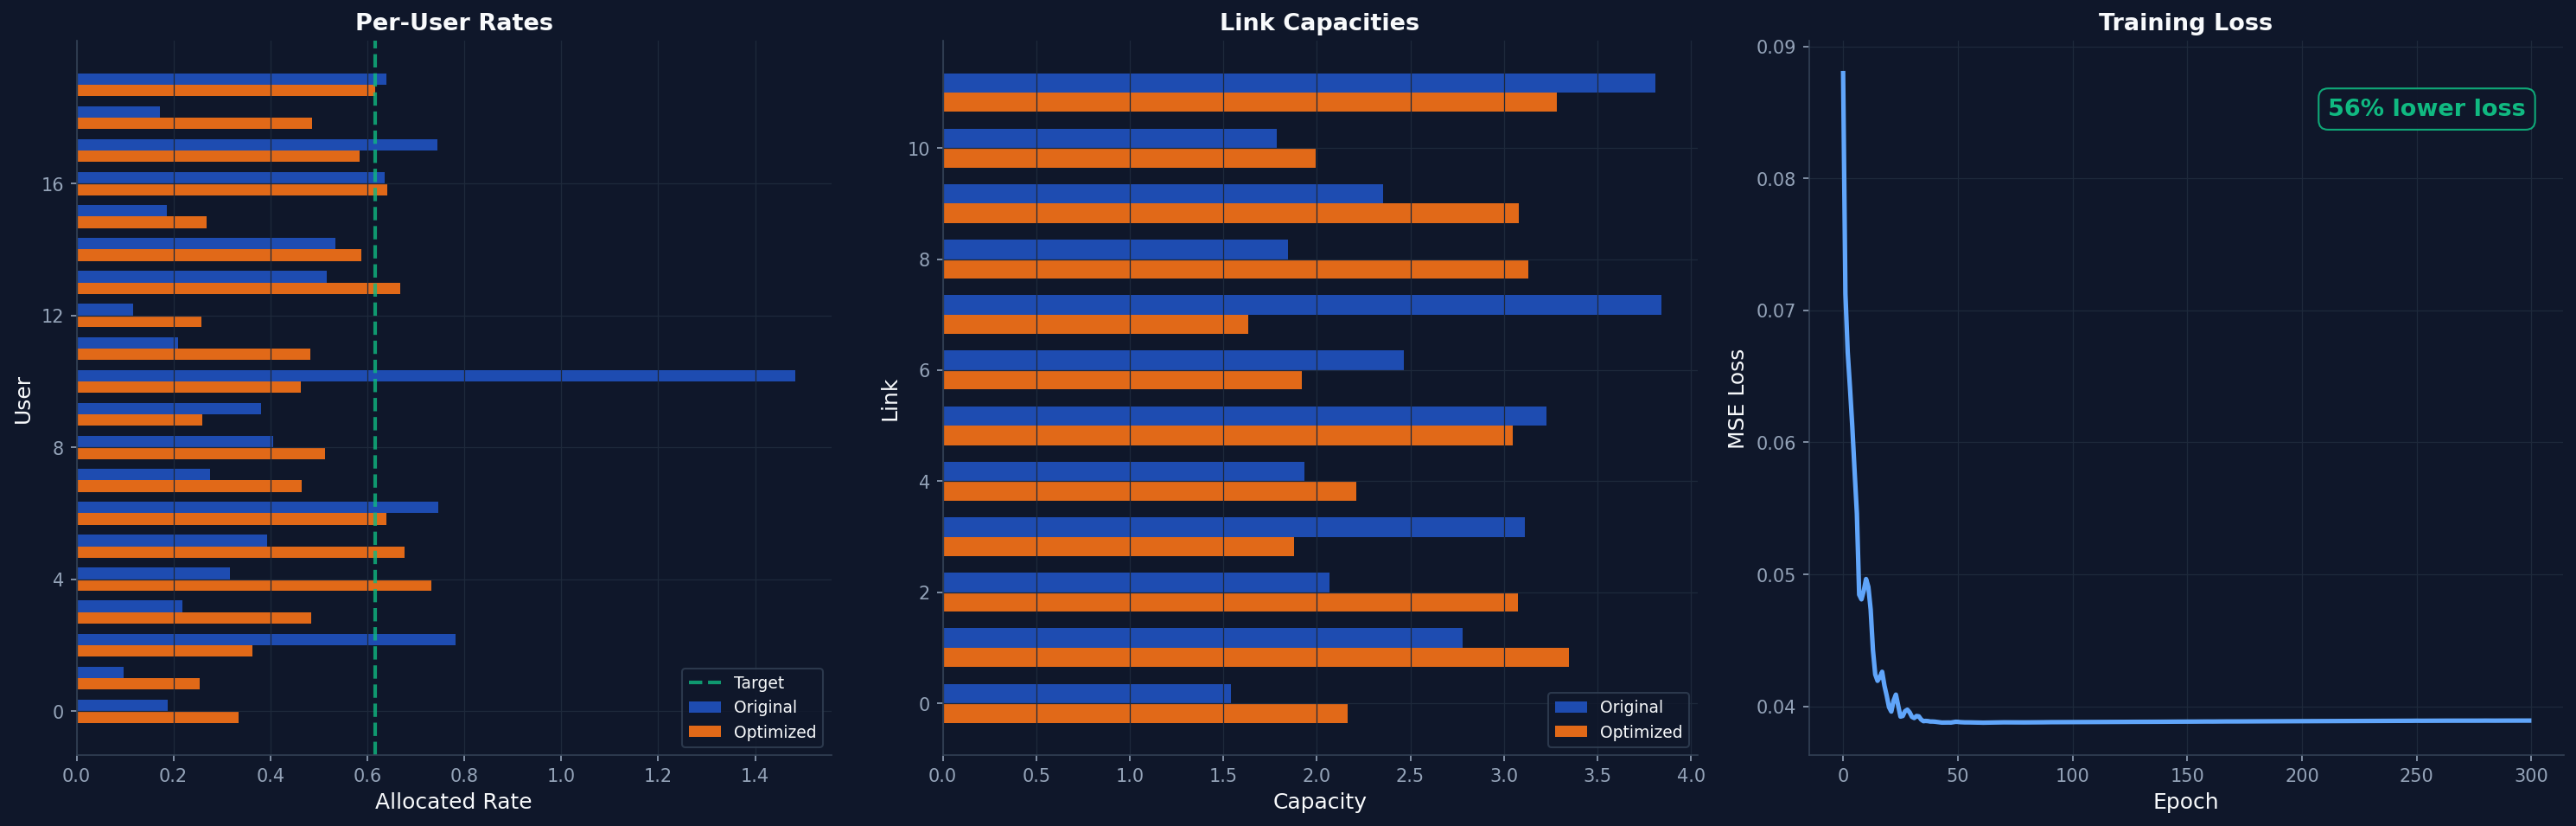

Saved hero image to ../assets/bandwidth_allocation.png


In [10]:
# --- Hero image: 3-panel ---
set_moreau_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

# Panel 1: Per-user rates — before/after grouped horizontal bars
ax = axes[0]
y_pos = np.arange(n_users)
bar_h = 0.35
order = np.argsort(x_target)

ax.barh(y_pos + bar_h/2, x_orig_np[order], height=bar_h,
        color=MOREAU_COLORS['primary'], alpha=0.7, label='Original')
ax.barh(y_pos - bar_h/2, x_final_np[order], height=bar_h,
        color=MOREAU_COLORS['accent'], alpha=0.9, label='Optimized')
ax.axvline(x_target[0], color=MOREAU_COLORS['success'], linestyle='--',
           linewidth=2, alpha=0.8, label='Target')
ax.set_xlabel('Allocated Rate')
ax.set_ylabel('User')
ax.set_title('Per-User Rates', fontsize=13)
ax.legend(loc='lower right', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155', fontsize=9)
ax.set_yticks(range(0, n_users, 4))

# Panel 2: Link capacities — before/after grouped bars
ax = axes[1]
y_pos_links = np.arange(n_links)
ax.barh(y_pos_links + bar_h/2, c_base, height=bar_h,
        color=MOREAU_COLORS['primary'], alpha=0.7, label='Original')
ax.barh(y_pos_links - bar_h/2, c_final_np, height=bar_h,
        color=MOREAU_COLORS['accent'], alpha=0.9, label='Optimized')
ax.set_xlabel('Capacity')
ax.set_ylabel('Link')
ax.set_title('Link Capacities', fontsize=13)
ax.legend(loc='lower right', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155', fontsize=9)

# Panel 3: Training loss curve
ax = axes[2]
ax.plot(losses, color=MOREAU_COLORS['primary_light'], linewidth=2.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss', fontsize=13)

improvement = (1 - losses[-1] / losses[0]) * 100
ax.annotate(
    f'{improvement:.0f}% lower loss',
    xy=(0.95, 0.92), xycoords='axes fraction',
    ha='right', va='top', fontsize=13, fontweight='bold',
    color=MOREAU_COLORS['success'],
    bbox=dict(boxstyle='round,pad=0.4', facecolor=MOREAU_COLORS['bg_dark'],
              edgecolor=MOREAU_COLORS['success'], alpha=0.9),
)

plt.tight_layout()
plt.savefig('../assets/bandwidth_allocation.png', bbox_inches='tight',
            facecolor=MOREAU_COLORS['bg_dark'])
plt.show()
set_moreau_style()
print("Saved hero image to ../assets/bandwidth_allocation.png")

## Training Animation

Watch the user rates converge toward the target and link capacities redistribute as training progresses.

Saved 15-frame animation to ../assets/bandwidth_allocation_anim.gif



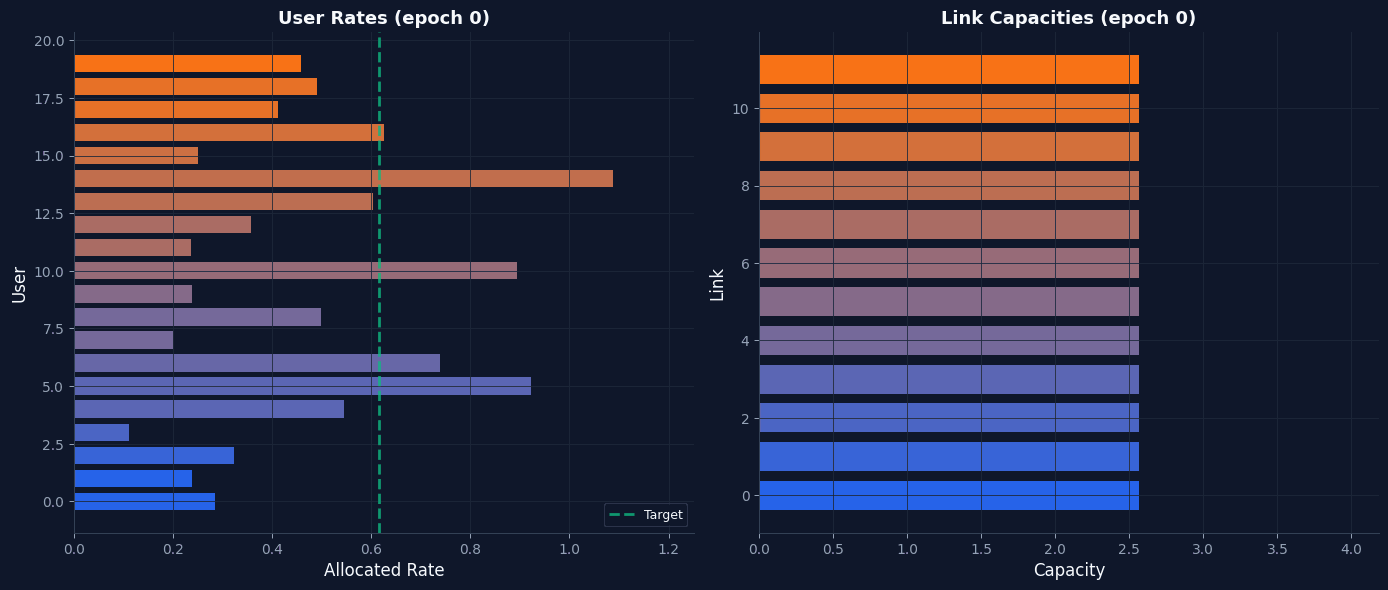

In [11]:
# --- Training animation ---
set_moreau_dark_style()

# Recompute rates for snapshot capacities (including epoch 0)
all_snap_x = []
for c_snap in snapshots_c:
    with torch.no_grad():
        c_t = torch.tensor(c_snap, dtype=torch.float64, device=device)
        x_s, = layer(c_t)
    all_snap_x.append(x_s.cpu().numpy())

# Pick ~15 evenly spaced frames
n_total = len(snapshots_c)
if n_total > 15:
    indices = np.linspace(0, n_total - 1, 15, dtype=int)
else:
    indices = np.arange(n_total)

# Axis limits
x_rate_max = max(arr.max() for arr in all_snap_x) * 1.15
c_cap_max = max(arr.max() for arr in snapshots_c) * 1.15

user_colors = moreau_gradient(n_users)
link_colors = moreau_gradient(n_links)

frames = []
for idx in indices:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    rates_snap = all_snap_x[idx]
    caps_snap = snapshots_c[idx]
    ep = snapshot_epochs[idx] if idx < len(snapshot_epochs) else n_epochs

    # Left: user rate bars
    ax1.barh(range(n_users), rates_snap, color=user_colors,
             edgecolor='none', height=0.75)
    ax1.axvline(x_target[0], color=MOREAU_COLORS['success'], linestyle='--',
                linewidth=2, alpha=0.8, label='Target')
    ax1.set_xlim(0, x_rate_max)
    ax1.set_xlabel('Allocated Rate')
    ax1.set_ylabel('User')
    ax1.set_title(f'User Rates (epoch {ep})', fontsize=13)
    ax1.legend(loc='lower right', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
              edgecolor='#334155', fontsize=9)

    # Right: link capacity bars
    ax2.barh(range(n_links), caps_snap, color=link_colors,
             edgecolor='none', height=0.75)
    ax2.set_xlim(0, c_cap_max)
    ax2.set_xlabel('Capacity')
    ax2.set_ylabel('Link')
    ax2.set_title(f'Link Capacities (epoch {ep})', fontsize=13)

    plt.tight_layout()
    frames.append(fig_to_pil(fig))
    plt.close(fig)

gif_path = '../assets/bandwidth_allocation_anim.gif'
save_gif(frames, gif_path, fps=4)
print(f"Saved {len(frames)}-frame animation to {gif_path}")
display_gif(gif_path)

## Gradient Flow

**Forward:**
$$c \;\xrightarrow{\text{solve power cone program}}\; x^*(c) \;\rightarrow\; \mathcal{L} = \|x^* - x_{\text{target}}\|^2$$

**Backward:**
$$\frac{\partial \mathcal{L}}{\partial c} = \frac{\partial \mathcal{L}}{\partial x^*} \cdot \frac{\partial x^*}{\partial c}$$

The Jacobian $\partial x^*/\partial c$ comes from implicit differentiation of the KKT conditions
of the power cone program. The power cone barrier is smooth, so the KKT system is well-conditioned
and implicit differentiation produces accurate gradients.

---

**Key takeaways:**
- **Power cones** are the natural cone for alpha-fairness — `cp.power(x, p)` maps directly to `Cones(power_alphas=[p, ...])`
- First **power cone example** in the gallery, demonstrating Moreau's full cone support
- The fairness-throughput Pareto frontier shows how the power parameter $p$ controls the tradeoff
- **cvxpylayers + Moreau** makes bilevel optimization over power cone programs seamless: define in CVXPY, differentiate with one line
- Learning optimal link capacities by backpropagating through the fair allocation solver achieves significantly more equal rates under the same budget